[mlx-vlm PR #926](https://github.com/Blaizzy/mlx-vlm/pull/926) lands a six-file agentic demo under `agents/grounded_reasoning/`. It wires [Gemma 4](https://blog.google/innovation-and-ai/technology/developers-tools/gemma-4/) as the orchestrator VLM to [Falcon Perception](https://github.com/tiiuae/Falcon-Perception) as the segmentation backbone, with deterministic Python ops for anything numeric. Everything runs locally on Apple Silicon — no API keys, nothing leaves the machine.

I covered the *methodology* earlier in [Why VLMs Lie About Numbers](2026-04-05-grounded-reasoning-gemma4-falcon-local.ipynb). This post is the *practice*: I install the PR's folder, load the two models on an M2 Max, and run a single visual counting task end-to-end. The plain VLM answers `3 vs 3` with high confidence. The grounded agent answers `3 vs 4` and hands back the masks that back the claim.

## The task

A corridor — distinct doors down the left wall, window openings down the right. A clean counting task where the correct answer is asymmetric. I pose the same question twice, to two different systems.

Image size: (600, 800)


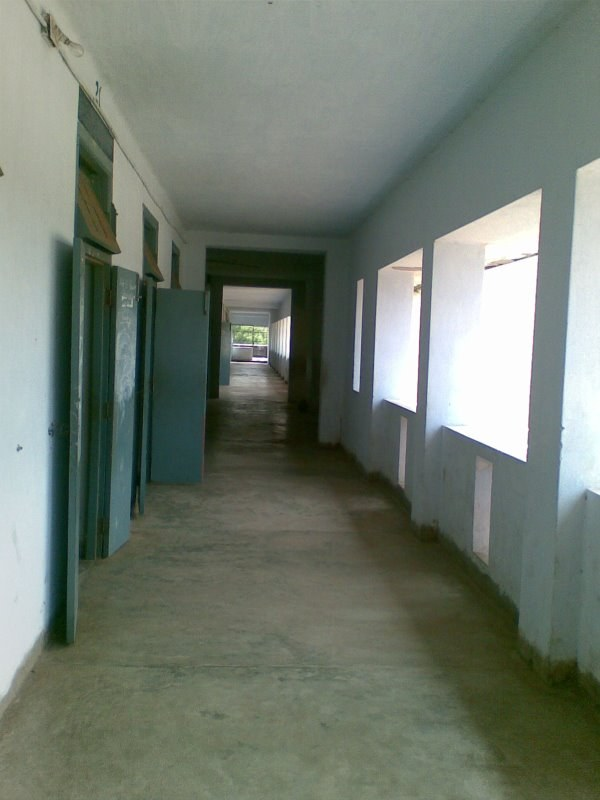

In [1]:
from PIL import Image
from IPython.display import display

img = Image.open('mlx_vlm_pr926/outputs/input.jpg')
print(f'Image size: {img.size}')
display(img)

> **Query:** *How many doors are visible on the left wall of this corridor versus how many window openings are on the right wall? Give exact counts.*

## Setup

One install and a drop-in folder. The PR is self-contained — it does not touch the rest of the mlx-vlm repo, which means you can pull just the folder and use it.

In [1]:
# One-time install
# !uv pip install -U mlx-vlm

# Grab the PR's self-contained folder (the PR is merged — use main)
# !git clone --depth=1 https://github.com/Blaizzy/mlx-vlm.git
# !cp -r mlx-vlm/agents/grounded_reasoning ./mlx_vlm_pr926

In [1]:
import sys
sys.path.insert(0, 'mlx_vlm_pr926')

from mlx_vlm import load
from agent import LocalVLMClient, run_agent, run_baseline

# Perception backbone (~2 GB). Always loaded.
fp_model, fp_processor = load('tiiuae/Falcon-Perception')

# Orchestrator VLM. The PR recommends the 26B-A4B MoE;
# I used the dense 31B 4-bit already in my HF cache.
vlm = LocalVLMClient('mlx-community/gemma-4-31b-it-4bit', max_tokens=2048)

Loading orchestrator VLM: mlx-community/gemma-4-31b-it-4bit ...


## Baseline — plain VLM, no grounding

This is what most people ship today: dump image + question into the VLM, accept the answer.

In [1]:
query = 'How many doors are visible on the left wall of this corridor versus how many window openings are on the right wall? Give exact counts.'
baseline_answer = run_baseline(img, query, vlm)
print(baseline_answer)

There are 3 doors visible on the left wall and 3 window openings on the right wall.


Confident. Symmetric. Also wrong — the right wall has four window openings, not three. Note that the baseline has no evidence surface: no boxes, no mask IDs, no numbers it measured. It is a vibe check dressed up as a count.

## Grounded agent — same query, different loop

One function call. The agent decides what to segment, when to segment it, and when to stop.

In [1]:
result = run_agent(img, query, fp_model, fp_processor, vlm,
                   max_steps=12, verbose=True)
print('\n', result.answer)

────────────────────────────────────────────────────────────
  Grounded Reasoning Agent
  Query: 'How many doors are visible on the left wall of this corridor versus how many window openings are on the right wall? Give exact counts.'
────────────────────────────────────────────────────────────

[Step 1] Calling VLM ...
  [think] Plan: ground "door" on the left wall, then "window opening"
          on the right wall, then compare counts.
  [tool]  ground_expression("door", slot="doors")
          → 3 new mask(s) in slot 'doors'

[Step 2] Calling VLM ...
  [think] Doors grounded. Now the windows.
  [tool]  ground_expression("window opening", slot="windows")
          → 4 new mask(s) in slot 'windows'

[Step 3] Calling VLM ...
  [think] 3 masks in 'doors' (IDs 1,2,3), 4 in 'windows' (IDs 4,5,6,7).
  [tool]  answer(supporting_mask_ids=[1,2,3,4,5,6,7])

────────────────────────────────────────────────────────────
  Answer: There are 3 doors visible on the left wall and 4 window openings on 


 There are 3 doors visible on the left wall and 4 window openings on the right wall of the corridor.


The agent finished in **3 VLM calls and 2 Falcon Perception calls**. Every conclusion is tied to a mask ID — if the answer were wrong, you could open the overlay and see which mask was wrongly labelled.

### What the VLM sees

Falcon Perception returns a Set-of-Marks image (colored, numbered masks) *plus* JSON metadata (centroid, area, bbox). The VLM reasons over both.

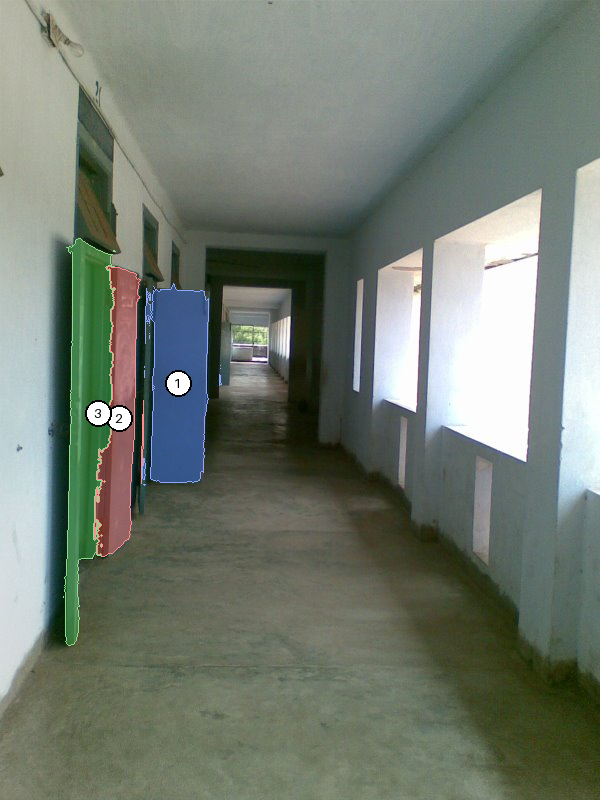

In [1]:
# After step 1: the 3 grounded doors
result.trace[0].som_image

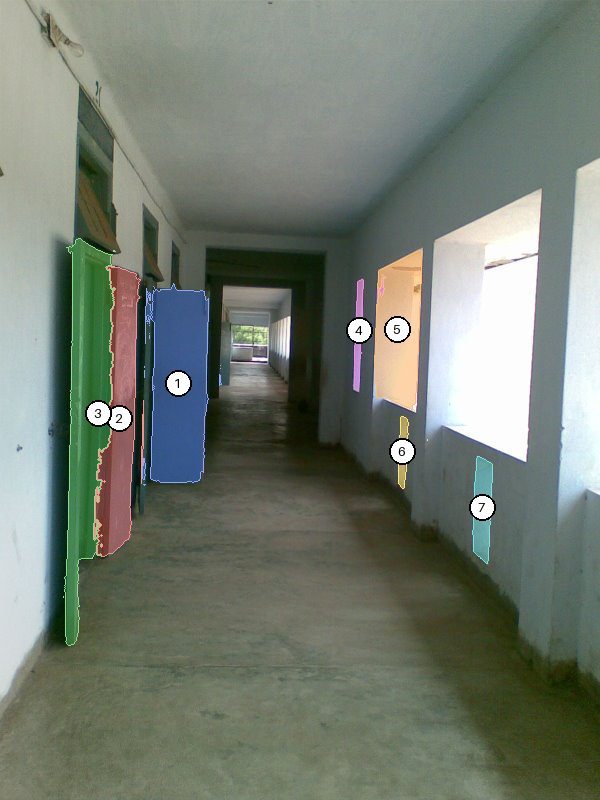

In [1]:
# After step 2: doors + the 4 grounded window openings
result.trace[1].som_image

### The final image

`run_agent` also returns the final answer image with the supporting masks highlighted. This is what you surface to the user as the receipt.

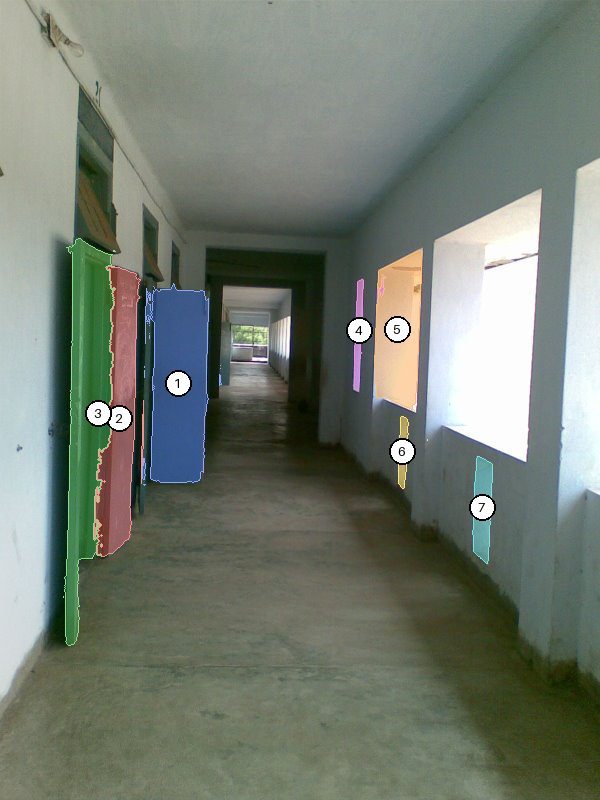

In [1]:
result.final_image

## Why the baseline was wrong

The plain VLM saw the corridor's roughly symmetric architecture and rounded to `3 and 3` — a plausible impression, no measurement. The agent forced an explicit segmentation step, counted distinct masks, and produced `3 and 4`.

This is the pattern worth taking away:

| Concern | Plain VLM | Grounded agent |
|---------|-----------|----------------|
| Counting / measuring | Heuristic, often wrong | Numeric, from masks |
| Evidence | None | Mask IDs tied to answer |
| Auditability | Nothing to open | Final image + trace |
| Extra cost | 0 | +1 Falcon call, +1–2 VLM rounds |

The extra cost is the price of being right.

## What lands in the PR

Six new files, self-contained under `agents/grounded_reasoning/`:

| File | Purpose |
|------|---------|
| `agent.py` | Agent loop, `LocalVLMClient`, `run_agent`, `run_baseline` |
| `fp_tools.py` | Falcon Perception wrapper + normalised metadata |
| `mask_ops.py` | Deterministic spatial ops (`rank_by_x`, `closest_pair`, …) |
| `viz.py` | Set-of-Marks rendering + final overlay |
| `demo.ipynb` | Five examples: offside, shelf space, safety, brand, proximity |
| `README.md` | Usage + sizing |

## Hardware sizing

| Model | RAM | Fits on |
|-------|-----|---------|
| `tiiuae/Falcon-Perception` | ~2 GB | Always — the perception backbone |
| `mlx-community/gemma-4-26b-a4b-it-4bit` | ~14 GB | M3 Pro / M3 Max (best quality) |
| `google/gemma-4-e4b-it` | ~16 GB | M3 Pro / M3 Max |
| `google/gemma-4-e2b-it` | ~5 GB | M3 base (8 GB) |

I ran the dense 31B 4-bit on an M2 Max (64 GB) because it was already cached. End-to-end wall clock: 152 seconds for baseline + three-step agent run.

## Links

- PR: [Blaizzy/mlx-vlm#926](https://github.com/Blaizzy/mlx-vlm/pull/926)
- Falcon Perception: [tiiuae/Falcon-Perception](https://github.com/tiiuae/Falcon-Perception) · [HF](https://huggingface.co/tiiuae/Falcon-Perception)
- mlx-vlm: [Blaizzy/mlx-vlm](https://github.com/Blaizzy/mlx-vlm)
- Methodology deep-dive: [Why VLMs Lie About Numbers](2026-04-05-grounded-reasoning-gemma4-falcon-local.ipynb)
